# A/B-тестирование изменения дизайна главной страницы стримингового сервиса PineApple Music

## Поставленная задача

Историческая конверсия стримингового сервиса `PineApple Music` составляет 12%. Маркетинговый отдел сделал предположение, что изменение дизайна главной страницы может повысить конверсию. Минимальный детектируемый эффект (MDE) был определен как 1 п.п. - прирост конверсии меньше этого значения не будет считаеться экономически значимым для внедрения нового дизайна.<br>
Дизайн-команда разработала новый вариант страницы - с другим заголовком и более заметной кнопкой «Попробовать бесплатно 30 дней».<br>
Был запущен A/B тест: часть пользователей видела старую страницу (control), часть - новую (treatment).<br>
Цель - проверить, увеличивает ли новый дизайн процент пользователей, оформивших подписку.

***Метрика для оценки*** - конверсия $CR$ (доля пользователей, оформивших подписку)<br>
***Нулевая гипотеза $H_0$*** - $CR_{control}$ = $CR_{treatment}$<br>
***Альтернативная гипотеза $H_1$*** - $CR_{control}$ &#x02260; $CR_{treatment}$<br>
***Уровень значимости $\alpha$*** = 0.05<br>
***Мощность теста (1 - $\beta$)*** = 0.8

## Импортируем данные

In [2]:
# импорт библиотек для работы с данными
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy import stats as sts
from statsmodels.stats.proportion import proportions_ztest

In [3]:
# импорт данных из файла
df = pd.read_csv('ab_data_pineapple.csv')

In [4]:
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


## Разведочный анализ данных (Exploratory data analysis)

In [5]:
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


### Данные о датафрейме

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   user_id       294478 non-null  int64
 1   timestamp     294478 non-null  str  
 2   group         294478 non-null  str  
 3   landing_page  294478 non-null  str  
 4   converted     294478 non-null  int64
dtypes: int64(2), str(3)
memory usage: 11.2 MB


In [7]:
df.describe()

,user_id,converted
count,294478.000000,294478.000000
mean,787974.124733,0.119659
std,91210.823776,0.324563
min,630000.000000,0.000000
25%,709032.250000,0.000000
50%,787933.500000,0.000000
75%,866911.750000,0.000000
max,945999.000000,1.000000


### Проверка на наличие пропусков и дубликатов

In [8]:
# проверка на наличие пропусков
df.isnull().sum()

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

In [9]:
# проверка на наличие дубликатов
df.duplicated().sum()

np.int64(0)

Дубликатов и нулевых значений не обнаружено

### Проверка имеющихся значений в колонах group и landing_page

In [10]:
df['group'].unique()

<StringArray>
['control', 'treatment']
Length: 2, dtype: str

In [11]:
df['landing_page'].unique()

<StringArray>
['old_page', 'new_page']
Length: 2, dtype: str

In [12]:
df['converted'].unique()

array([0, 1])

В исследуемых колонках содержится по два уникальных значения, что позволяет использовать данный датафрейм для анализа

### Оценка корректности подобранных групп

Общая конверсия двух выборок лежит в диапазоне [0,1], некорректных значений нет

Проверка соответствия принадлежности группы к соответствующей странице

In [33]:
df.groupby(['group', 'landing_page']).size().unstack()

landing_page,new_page,old_page
group,,
control,1928,145274
treatment,145311,1965


Обнаружены несоответствия: 1928 пользователей из группы control посетили new_page, 1965 пользователей из группы treatment посетили old_page

Очистка несоответствующих данных

In [14]:
df_clean = df[((df['group'] == 'control') & (df['landing_page'] == 'old_page')) | ((df['group'] == 'treatment') & (df['landing_page'] == 'new_page'))]

In [15]:
df_clean.groupby(['group', 'landing_page']).size()

group      landing_page
control    old_page        145274
treatment  new_page        145311
dtype: int64

In [16]:
df_clean['group'].value_counts(normalize=True)

group
treatment    0.500064
control      0.499936
Name: proportion, dtype: float64

Соотношение количества пользователей в группах приближено к 50/50 - по количеству пользователей группы равноценны

Проверка распределения пользователей групп по дате

In [17]:
df_clean['timestamp'] = df_clean['timestamp'].astype('datetime64[ns]')
df_clean['date'] = df_clean['timestamp'].dt.to_period('D')

In [18]:
df_clean_plot = df_clean.groupby(['date', 'group']).user_id.count().reset_index()
df_clean_plot.tail(4)

,date,group,user_id
42,2017-01-23,control,6716
43,2017-01-23,treatment,6633
44,2017-01-24,control,3754
45,2017-01-24,treatment,3681


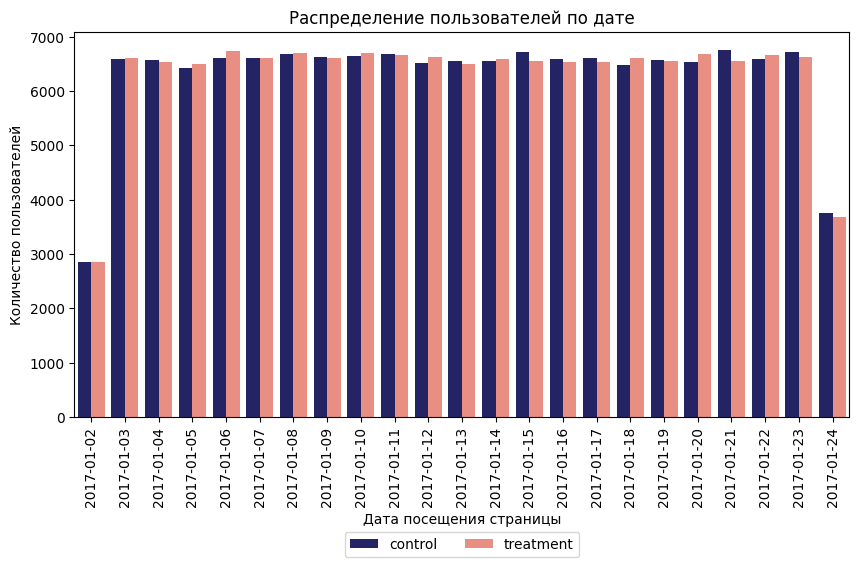

In [19]:
plt.figure(figsize=(10, 5))

ax = sns.barplot(data=df_clean_plot,
            x='date',
            y='user_id',
            hue='group',
            palette=['midnightblue', 'salmon']
)

plt.title('Распределение пользователей по дате')
plt.xlabel('Дата посещения страницы')
plt.ylabel('Количество пользователей')

plt.xticks(rotation=90)

ax.legend(
    bbox_to_anchor=(0.5, -0.28),
    loc='upper center',
    ncol=2
)

plt.show()

Распределения количества пользователей по датам визуально сопоставимы. Аномальных всплесков активности не выявлено.

### Расчет конверсии по группам

In [20]:
cr_control = df_clean[df_clean['group'] == 'control'].converted.mean()*100
cr_treatment = df_clean[df_clean['group'] == 'treatment'].converted.mean()*100
uplift_absolute = (cr_treatment - cr_control)
uplift_relative = ((cr_treatment - cr_control)/cr_control)*100
print(f'''Конверсия группы control: {round(cr_control, 2)} %
Конверсия группы treatment: {round(cr_treatment, 2)} %
Абсолютная величина эффекта (uplift): {round(uplift_absolute, 2)} п.п.
Относительная величина эффекта (relative uplift): {round(uplift_relative, 2)} %''')

Конверсия группы control: 12.04 %
Конверсия группы treatment: 11.88 %
Абсолютная величина эффекта (uplift): -0.16 п.п.
Относительная величина эффекта (relative uplift): -1.31 %


In [21]:
cr = df_clean.groupby('group').converted.mean().mul(100).reset_index()

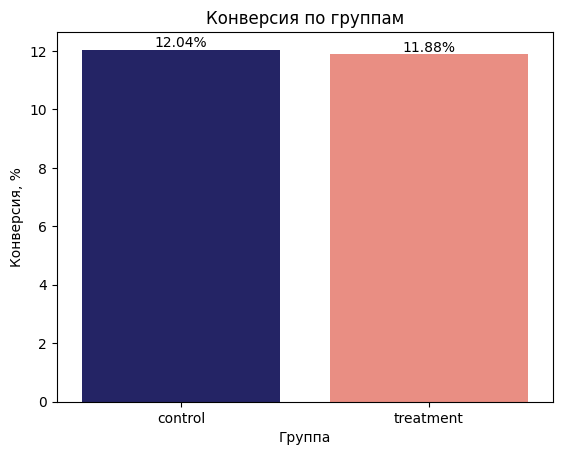

In [22]:
ax = sns.barplot(
    data=cr, 
    x='group',
    y='converted', 
    palette=['midnightblue', 'salmon'], 
    hue='group'
)

for i in ax.containers:
    plt.bar_label(i, fmt='%.2f%%')

plt.title('Конверсия по группам')
plt.ylabel('Конверсия, %')
plt.xlabel('Группа')

plt.show()

По результатам расчета конверсий по испытуемым группам обнаружено снижение конверсии в группе treatment на 0,16 п.п. По предварительной оценке можно сказать, что выборки не будут отличаться статистически, для оценки статистического различия необходим z-тест для пропорций.

## Оценка размера выборки

Для оценки достаточности размера выборки воспользуемся формулой для расчета размера выборки при сравнении пропорций

$$ n=\frac{(Z_{\frac{\alpha}{2}}\sqrt{2*p_1 (1-p_1)}+Z_{\beta}\sqrt{p_1(1-p_1)+p_2(1-p_2)})^2}{MDE^2} $$

где:</br>
$p_1$ - конверсия до изменений </br>
$p_2$ - конверсия после изменений. $p_2 = p_1+MDE$ </br>
$Z_{\frac{\alpha}{2}}$ - z-квантиль ошибки первого рода деленного на 2;</br>
$Z_{\beta}$ - z-квантиль ошибки второго рода;</br>
$p_1 (1-p_1)$ - дисперсия;</br>
$p_2(1-p_2)$ -дисперсия с учетом того, что среднее (конверсия) увеличится на MDE</br>
$MDE$ - минимальный детектируемый эффект. Расчитывается как $p_2 - p_1$

In [23]:
p1 = 0.12 # историческая конверсия
p2 = 0.13 # ожидаемая конверсия
var = p1 * (1 - p1) # дисперия группы control
var_with_mde = p2 * (1 - p2) # дисперсия с учетом MDE
mde = p2 - p1

Определим критические значения для статистической значимости (ошибки первого рода) $\alpha$ = 0,05

In [24]:
z_a = sts.norm.ppf(0.05/2)
print(z_a)

-1.9599639845400545


Критические значения для статистической значимости $\alpha$ = 0,05 составляют &#177;1,96

Определим критические значения для ошибки второго рода $\beta$ = 0,2

In [25]:
z_b = sts.norm.ppf(0.2)
print(z_b)

-0.8416212335729142


Для заданной мощности теста критическое значение составило z = 0,84

Расчитаем минимальный размер выборки неоходимый для проведения A/B-теста для обозначенного MDE

In [26]:
n = (((z_a * ((2 * var) ** 0.5)) + (z_b * ((var + var_with_mde) ** 0.5))) ** 2) / (mde ** 2)
print(n)

16752.59526736792


Размеры каждой из выборок

In [27]:
print(f'Минимальный требуемый размер одной выборки: {round(n)}')
print(f'Реальные размеры выборок: {df_clean.groupby('group').group.count().to_dict()}')

Минимальный требуемый размер одной выборки: 16753
Реальные размеры выборок: {'control': 145274, 'treatment': 145311}


Размер каждой из выборок (~145 000) превышает минимально необходимый размер выборки (16 753), что достаточно для обнаружения установленного MDE (1 п.п.)

## z-тест

Расчитаем количество оформленных подписок (положительных результатов) в каждой выборке

In [28]:
control_successes = df_clean[(df_clean['group'] == 'control') & df_clean['converted'] == 1].converted.count()
treatment_successes = df_clean[(df_clean['group'] == 'treatment') & df_clean['converted'] == 1].converted.count()

print(f'Количество успешных результатов в группе control: {control_successes}')
print(f'Количество успешных результатов в группе treatment: {treatment_successes}')

Количество успешных результатов в группе control: 17489
Количество успешных результатов в группе treatment: 17264


Создадим переменные с реальными размерами выборок

In [29]:
control_trials = df_clean[df_clean['group'] == 'control'].converted.count()
treatment_trials = df_clean[df_clean['group'] == 'treatment'].converted.count()

Считаем z-тест и p-value

In [30]:
z_test, p_value = proportions_ztest([control_successes, treatment_successes], [control_trials, treatment_trials])

print(f'z-тест: {round(z_test, 3)}')
print(f'p-value: {round(p_value, 3)}')

z-тест: 1.312
p-value: 0.19


Значение z-теста не превышает критические значения &#177;1,95.<br>
p-value превышает установленный уровень значимости 0,05.<br>
Таким образом, статистически значимых различий в конверсиях между группами не обнаружено, нулевая гипотеза $H_0$ не отвергается.

## Выводы и предложения

Изменение дизайна главной страницы в данном варианте не привело к увеличению конверсии. Дизайн страницы может не являться ключевым фактором, влияющим на решение пользователя оформить подписку.<br>
Для выявления истинных причин низкой конверсии рекомендуется провести дополнительные исследования на проверку следующих гипотез:
- высокая стоимость сервиса
- недостаточно большая библиотека музыки
- проблемы с UX

Для получения желаемого результата могут быть предложены следующие стратегии:
- скидка на 3 месяца подписки для новых пользователей
- улучшение условий сотрудничества с сервисом для артистов
- провести дополнительные UX-исследования

## Примечания

1. Т.к. проект учебный, для него были взяты уже готовые выборки. Соответственно, размер выборки не устанавливался перед тестом, а проверялся на соответствие уже непосредственно перед расчетом z-теста
2. За исторические данные были приняты данные, полученные от группы control